# Flutuações de um Vácuo Quântico

* PET Física - UFRN
* Petiano: Wallysson Pereira da Silva
* Data: 01/05/2026 

$\quad$ Neste projeto estaremos utilizando um resultado bem interessante da Teoria Quântica de Campos para simular o comportamento do vácuo. Como será desenvolvido mais adiante, esse resultado nos indica que o vácuo não é totalmente isento de energia, ainda há pequenas flutuações, que visualizaremos através de plots. Com isso em mente, esse `Notebook` foi dividido nas seguintes seções 

1. Introdução Teórica;

2. Visualização estática;

3. Evolução temporal

4. Função de correlação

5. Conclusão.

## Importando bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import kn # Função de Bessel para a curva teórica
import matplotlib.animation as animation

## Informações sobre as bibliotecas

In [2]:
%load_ext version_information
%version_information Matplotlib, Numpy

Software versions
Python 3.13.0 64bit [MSC v.1941 64 bit (AMD64)]
IPython 8.29.0
OS Windows 11 10.0.26200 SP0
Matplotlib 3.9.2
Numpy 2.1.3
Mon Apr 27 18:38:08 2026 Hora Padrão de Buenos Aires

## 1. Introdução Teórica

$\quad$ A existência do vácuo sempre foi uma questão filosófica bem relevante em diversas sociedades. Na própria cultura grega, relacionava-se a ideia de vácuo — entendida como a ausência total de matéria — com a existência do movimento. Dentro do mundo grego antigo, apesar das divergências entre os ditos eleatas e os atomistas sobre a existência ou não do vácuo, ambos concordavam que, se ele existesse, o movimento existiria. Mais tarde, Aristóteles estabeleceu que a natureza tenderia naturalmente a preencher os espaços vazios que surgissem, logo impossibilitando a existência do vácuo **[1]**.

$\quad$ A noção cotidiana atual sobre o tema, isto é, a de ausência absoluta de matéria e energia, alinha-se perfeitamente à interpretação da física clássica. Assim, imaginamos que seria possível pegar uma caixa, retirar todas as partículas, isolá-la completamente do ambiente externo, restando tão somente o absoluto nada em seu interior. No entanto, a Teoria Quântica de Campos (QFT) demonstrou de maneira satisfatória que essa visão está incompleta. O vácuo não é apenas um palco vazio, mas sim um meio com rica dinâmica. Neste trabalho, simularemos o comportamento do campo escalar de Klein-Gordon, o modelo mais simples da teoria de campos.

$\quad$ Dentro do contexto do campo escalar de Klein-Gordon, buscaremos simular o estado de menor energia possível: o estado de vácuo. Para tal, é importante destacar que a QFT abandona a ideia de um universo feito de entidades físicas isoladas, ao passo que eleva o campo ao patamar de bloco fundamental da natureza. Pense num campo como uma entidade que permeia todo o espaço (e o tempo) de forma contínua por toda a sua extensão. O exemplo mais comum seria o de um campo de temperatura.

$\quad$ Nesse contexto de campos permeando todo o espaço, o que nós antes conhecíamos como "partícula", agora é apenas uma ondulação ou excitação empacotada viajando através desse campo. Sob esse paradigma, poderíamos pensar que o vácuo seria representado por um campo totalmente plano e imóvel, com energia zero. No entanto, fazendo jus à parte "quântica" da QFT, o Princípio da Incerteza de Heisenberg proíbe essa imobilidade absoluta. Assim como não podemos saber a posição e a velocidade de um elétron ao mesmo tempo, não podemos fixar o valor do campo e sua taxa de variação simultaneamente. Como resultado, o campo sofre oscilações probabilísticas contínuas, criando minúsculas ondas de energia que aparecem e desaparecem quase instantaneamente. Essas são as chamadas flutuações de vácuo.

$\quad$ Para simular esse mar quântico computacionalmente, utilizamos a matemática da quantização canônica. Nesse paradigma físico, o campo $\phi(x)$ e sua densidade de momento $\Pi(x)$ são promovidos a operadores: $\phi(x) \to \hat{\phi}(x)$ e $\Pi(x) \to \hat{\Pi}(x)$. Junto a isso, impomos relações de comutação entre esses dois entes matemáticos. Por exemplo, avaliando os campos num mesmo instante de tempo $t$, temos $[\hat{\phi}(t,\textbf{x}), \hat{\Pi}(t,\textbf{y})] = i\delta^{(3)}(\textbf{x}-\textbf{y})$. Assim como muito bem abordado na referência [1], nós podemos expressar o operador campo em função dos operadores de criação e aniquilação ($\hat{a}^\dagger$ e $\hat{a}$, respectivamente):

$$\hat{\phi}(x) = \int \frac{d^{d}p}{(2\pi)^{\frac{d}{2}}}\frac{1}{\sqrt{2\omega_p}}\left (\hat{a}_pe^{i\textbf{p}\cdot \textbf{x}} + \hat{a}_{p}^{\dagger}e^{-i\textbf{p}\cdot \textbf{x}}  \right),$$

onde $d$ é a dimensionalidade e, como utiliza-se o sistema de unidades naturais, a energia terá a mesma dimensão de frequência.

Podemos argumentar que, como o operador de aniquilação $\hat{a}_p$ atua diminuindo uma quantidade $\omega_p$ do modo de oscilação $p$, para prevenir instabilidades que levariam a divergências no sistema, deve existir um estado de energia mínima $\ket{0}$ tal que $\hat{a}_p\ket{0} = 0$ para todo $p$. Usando esse argumento, e a partir da forma explícita de $\hat{a}_{p}$ em função dos operadores de campo espaciais ($\hat{\phi}_{p}$ e $\hat{\Pi}_{p}$):

$$\hat{a}_p = \sqrt{\frac{\omega_p}{2}}\hat{\phi}_p + \frac{i}{\sqrt{2\omega_p}}\hat{\Pi}_p,$$

é possível chegar à forma do estado do vácuo, utilizando a representação dentro do espaço de configurações do campo:

$$\langle \phi | 0 \rangle = \Psi_0[\phi] = \mathcal{N}\exp{\left(-\frac{1}{2}\int d^{3}p \ \omega_p |\phi_p|^2\right)},
\tag{1}$$

com $\mathcal{N}$ sendo apenas uma constante de normalização. Dessa expressão já tiramos uma consideração importante: o vácuo tem um comportamento gaussiano.

$\quad$ Partindo para a interpretação estatística desse estado, temos que a probabilidade de encontrarmos o vácuo flutuando com uma determinada configuração de campo $\phi$ é dada pelo módulo quadrado da função de onda:

$$\mathcal{P}[\phi] \propto \exp{\left( -\int d^{3}p \ \omega_p |\phi_p|^2\right)}.$$

Conclui-se, a partir desse fato, que a variância para um dado modo $p$ é estritamente proporcional a $\frac{1}{\omega_p}$.


## 2. Visualização estática 

$\quad$ Utilizando todo esse ferramental desenvolvido, vamos agora partir para a simulação. Primeiramente vamos definir as constantes da nossa simulação.

In [3]:
# --- 1. Parâmetros da Simulação ---
N = 512        # Tamanho da grade (512x512 pixels). Quanto maior, mais resolução.
L = 10.0       # Tamanho físico do nosso "pedaço de universo"
m = 0.5        # Massa da partícula do campo (evita divisão por zero)

$\quad$ Na física analítica, o espaço é contínuo e infinito. No computador, precisamos de uma grade finita e discreta. A função np.fft.fftfreq que utilizaremos gera as frequências espaciais permitidas nessa nossa grade de tamanho $N \times N$. Físicamente, estamos definindo todos os vetores de onda $\vec{k}$ (ou momentos, já que $\hbar=1$) possíveis que cabem na nossa "caixa" de simulação de tamanho $L$. A função np.meshgrid cruza essas frequências para criar um plano 2D de momentos, permitindo analisar ondas se propagando em qualquer direção.

In [4]:
# Aqui definimos as frequências (ondas) possíveis na nossa grade
kx = np.fft.fftfreq(N, d=L/N) * 2 * np.pi
ky = np.fft.fftfreq(N, d=L/N) * 2 * np.pi
KX, KY = np.meshgrid(kx, ky)

$\quad$ Agora vamos calcular a energia de cada modo do campo. Essa linha é a implementação direta da relação de dispersão da relatividade restrita no sistema de unidades naturais ($c=1$):$$\omega_k = \sqrt{|\vec{k}|^2 + m^2}$$Para cada "pixel" no nosso espaço de momentos (uma onda específica), calculamos o seu custo energético $\omega_k$. O termo da massa $m$ garante que até as ondas de momento zero tenham uma energia mínima (evitando divisões por zero nas próximas etapas e modelando um campo massivo).

In [5]:
# A relação de dispersão: omega_k = sqrt(|k|^2 + m^2)
omega_k = np.sqrt(KX**2 + KY**2 + m**2)

Lembra que provamos que o vácuo quântico é ditado por um funcional de probabilidade Gaussiano? É exatamente isso que a função np.random.normal(0, 1) faz. Como os operadores $\hat{a}$ e $\hat{a}^\dagger$ não comutam, o valor do campo flutua aleatoriamente em torno do zero. Construímos um ruído branco complexo sorteando valores de uma distribuição normal para simular o comportamento probabilístico desses operadores para cada frequência isolada do nosso universo simulado.

In [6]:
# --- 4. Gerar o "Ruído Quântico" ---

# Simulamos os operadores de criação/aniquilação como números complexos aleatórios.
# Eles seguem uma distribuição normal (Gaussiana).
ruido_real = np.random.normal(0, 1, (N, N))
ruido_imag = np.random.normal(0, 1, (N, N))
a_k = (ruido_real + 1j * ruido_imag) / np.sqrt(2)

Esta é a alma matemática da quantização! Da expansão canônica do campo, sabemos que a amplitude de flutuação de cada modo no vácuo é modulada pela sua energia. A linha de código implementa o fator:$$\frac{1}{\sqrt{2\omega_k}}$$Isso significa que dividimos o nosso ruído quântico puramente aleatório pela raiz da energia daquela onda. Fisicamente, isso diz que ondas de alta frequência (alta energia) flutuam muito pouco, enquanto ondas de baixa frequência flutuam com amplitudes muito maiores. É essa modulação que transforma um simples ruído branco de computador na textura física de um campo quântico.

In [7]:
# --- 5. A Equação do Campo ---
# Modulamos o ruído pela energia
phi_k = a_k / np.sqrt(2 * omega_k)

Até o passo anterior, nós tínhamos o campo descrito no espaço das frequências (momentos). A Transformada Inversa Rápida de Fourier 2D (np.fft.ifft2) faz a integral que soma todas essas infinitas ondas $\phi_k$, cada uma com sua fase e amplitude corretas, e as colapsa de volta para o espaço real. Como o campo escalar de Klein-Gordon descreve partículas neutras, o campo deve ser um valor real (um operador Hermitiano). Pegamos a parte real (np.real) apenas para descartar resíduos numéricos imaginários ínfimos que surgem do cálculo flutuante do computador.

In [8]:
# --- 6. Transformada Inversa de Fourier (IFFT) ---
# Pegamos as ondas no espaço dos momentos e transformamos no campo físico no espaço real.
phi_x = np.fft.ifft2(phi_k)

Esta etapa final pega nossa matriz matemática resultante e a transforma em uma imagem (um heatmap). O mapa de cores magma não está mostrando calor, mas sim os picos (positivos) e vales (negativos) das flutuações do campo $\phi(x)$ no espaço. Você está literalmente "fotografando" a manifestação visual do estado fundamental $|0\rangle$, visualizando as partículas virtuais fervilhando no vácuo simulado.

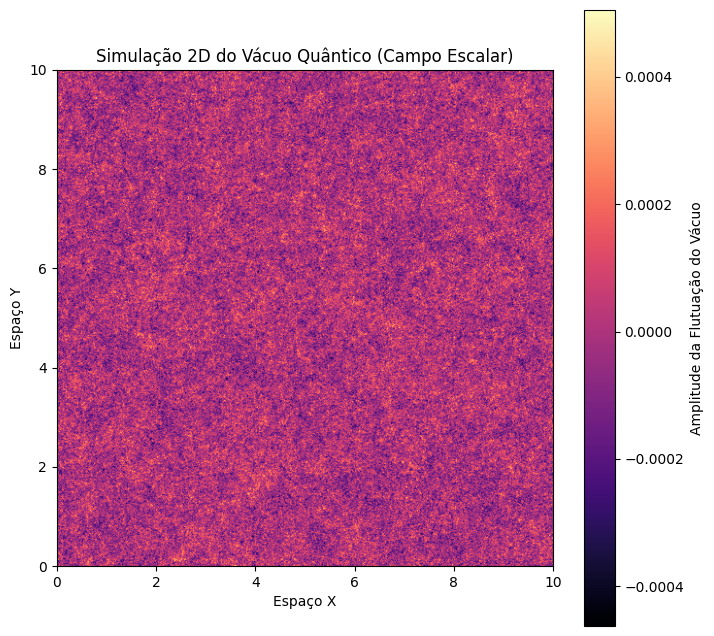

In [9]:
# O campo escalar físico é a parte real do resultado
campo_fisico = np.real(phi_x)

# --- 7. Visualização Inicial do Vácuo ---
plt.figure(figsize=(8, 8))
plt.imshow(campo_fisico, cmap='magma', extent=[0, L, 0, L])
plt.colorbar(label='Amplitude da Flutuação do Vácuo')
plt.title('Simulação 2D do Vácuo Quântico (Campo Escalar)')
plt.xlabel('Espaço X')
plt.ylabel('Espaço Y')
plt.show()


## 3. Função de Correlação

$\quad$ Na física clássica, o "vácuo" é o nada absoluto. Se o campo é zero em um ponto, ele é zero no ponto ao lado; não há correlação porque não há nada lá. No entanto, como já demonstrado, a QFT estabelesce um comportamento probabilístico para a presença de matéria no vácuo.
Então, pensamos que o estado fundamental (o nível de menor energia possível, que chamamos de vácuo) ferve constantemente com partículas e antipartículas virtuais surgindo e desaparecendo. São as chamadas flutuações de ponto zero. Embora a média global do campo seja zero ($\langle \phi \rangle = 0$), essas flutuações não ocorrem de forma totalmente isolada. Quando uma flutuação virtual surge no vácuo, sua influência se espalha pelo espaço ao seu redor antes de desaparecer. Isso significa que o vácuo possui uma "textura" espacial; regiões próximas no espaço estão intrinsecamente emaranhadas e influenciam umas às outras. Nesse contexto, podemos esperar que surge uma espécie de correlação entre os pontos do vácuo. Podemos pensar "Se eu medir uma flutuação quântica no ponto $x$, qual é a probabilidade estatística de que essa flutuação tenha influenciado o ponto vizinho $y$?".


$\quad$ Matematicamente, estamos pensando na chamada autocorrelação (uma espécie de influência mútua) entre pontos da nossa grade representando o vácuo quântico. Considerando o caso do estado do vácuo, formalmente podemos denotar a correlação de $\phi$ nos pontos $x$ e $x+\delta r$ por 
$$
\bra{0} \phi(x)\phi(x+\delta r) \ket{0}.
$$
Na Teoria Quântica de Campos (QFT), essa exata mesma métrica recebe outro nome: Função de Correlação de Dois Pontos a Tempos Iguais, ou simplesmente Propagador Espacial.

$\quad$ O vácuo é assumido como sendo homogêneo e isotrópico, logo podemos escolher um ponto qualquer e calcular a correlação do mesmo com o resto dos pontos da grade. Por conveniência, é conviente adotar $x =$ origem e calcular o $\delta r$ como sendo a distância de um ponto qualquer até a origem. Assim,
$$
cbra{0} \phi(0)\phi(\delta r) \ket{0}.
$$

Computacionalmente, calcular a correlação espacial varrendo a grade bidimensional pixel por pixel exigiria um esforço gigantesco (uma complexidade de tempo associada a $O(N^4)$). Para viabilizar a simulação, recorremos a um atalho poderoso do processamento de sinais: o Teorema de Wiener-Khinchin. Este teorema estabelece que, para processos aleatórios espacialmente estacionários (como é o caso do vácuo quântico homogêneo), a função de autocorrelação no espaço real é simplesmente a Transformada de Fourier do espectro de potência do vácuo. Lembrando que a amplitude do campo depende de $\frac{1}{\sqrt{\omega_k}}$, o espectro de potência é proporcional a $\frac{1}{\omega_k}$.A matemática nos diz que a correlação é calculada pela integral:$$\langle \phi(0)\phi(r) \rangle \propto \int \frac{d^2 k}{(2\pi)^2} \frac{1}{\sqrt{|\vec{k}|^2 + m^2}} e^{i \vec{k} \cdot \vec{r}}.$$

Com esse resultado em mente, vamos construir um código que exiba a autocorrelação do vácuo num mapa de calor.

$\quad$   

### 3.1 Autocorrelação 2D (Heatmap)

$\quad$ O Teorema de Wiener-Khinchin anteriormente introduzido fala sobre o campo no espaço das posições $x$, não no espaço dos momentos $k$. Assim, vamos usar a Transformada Inversa de Fourir para trazer o campo de volta pro espaço real dsa posições.  

$\quad$ Para esse passo, vamos utilizar o campo nos espaços do momento (o phi_k anteriormente já definido). O teorema estabelescer que a autocorrelação do campo vai ser a Transformada de Fourier do espectro de potência. Assim, calculamos o espectro de potência $|\phi(k)|^2$, logo após definimos uma variável para autocorr como sendo a Transformada de Fourier desse espectro. 

In [10]:
# --- Autocorrelação 2D ---
espectro_potencia = np.abs(phi_k)**2
espectro_potencia[0, 0] = 0 

autocorr_2d = np.real(np.fft.ifft2(espectro_potencia))
autocorr_2d = np.fft.fftshift(autocorr_2d)


$\quad$ Efetivamente já temos o gráfico de autocorrelação do campo. O plot será exibido no código abaixo.

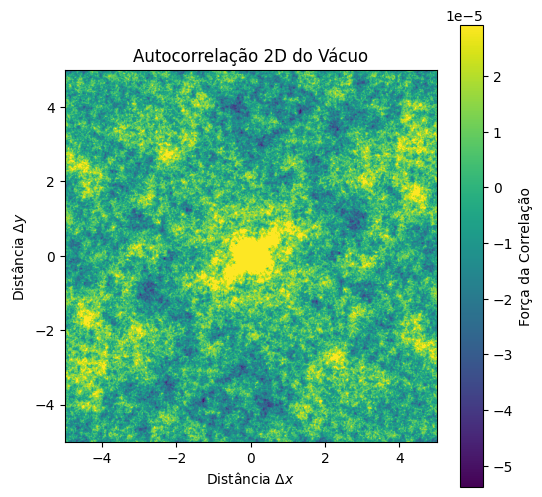

In [11]:
# --- Plot Heatmap ---
plt.figure(figsize=(6, 6))

vmax_corte = np.percentile(autocorr_2d, 98)
plt.imshow(
    autocorr_2d,
    cmap='viridis',
    extent=[-L/2, L/2, -L/2, L/2],
    vmax=vmax_corte
)

plt.title('Autocorrelação 2D do Vácuo')
plt.xlabel(r'Distância $\Delta x$')
plt.ylabel(r'Distância $\Delta y$')
plt.colorbar(label='Força da Correlação')

plt.show()

$\quad$ A teoria estabelesce que o valor esperado da autocorrelação  $\langle 0 | \phi(x)\phi(y) | 0 \rangle$ deveria ser perfeitamente isotrópica. Logicamente não observamos isso no plot anterior. A explicação para isso está justamente na palavra "valor esperado". 
O valor esperado é a média estatística de infinitas configurações possíveis do vácuo. No entanto, quando definimos "ruido_real = np.random.normal(0, 1, (N, N))", estamos sorteando aleatoriamente apenas uma única configuração do vácuo. Como a mecânica quântica é fundamentalmente probabilística, essa única configuração está cheia de flutuações estatísticas severas ao redor da média. Nesse contexto, o plot acima reproduz o gráfico de autocorrelação de apenas uma configuração estática. Para obter o comportamento isotrópico teórico, teríamos que simular inúmeros vácuos e valer uma média entre o mapa de cada correlação. A próxima seção desse `Notebook` lida exatamente com essa simulação.

### 3.2 Simulando Múltiplos Vácuos

$\quad$ Visando alcançar um vislumbre do comportamento médio da autocorrelação do vácuo, vamos simular $N = 1000$ vácuos, calcular e somar o espectro de potência de cada um, no final dividindo o valor do espectro pelo número de simulações. Após isso, calculamos a sua Transformada de Fourier, obtendo, assim como na seção anterior, autocorrelação desse espectro médio do vácuo.   

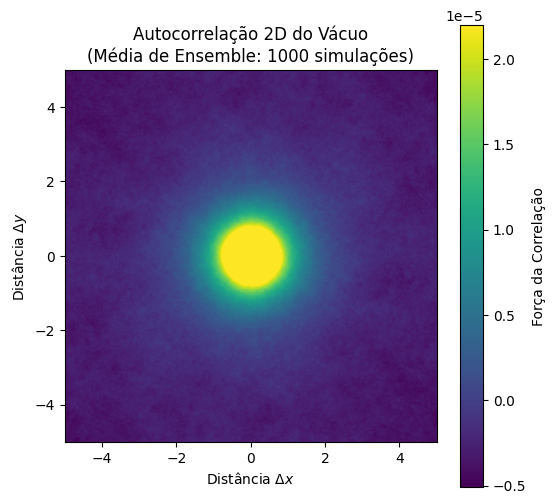

In [12]:
num_simulacoes = 1000

# Começa com zeros e vai somando o espectro de cada simulação.
soma_espectro = np.zeros((N, N))

# Loop para calcular a média estatística do espectro de potências do vácuo.
for i in range(num_simulacoes):
    # Gera o ruído quântico para um universo
    ruido_real = np.random.normal(0, 1, (N, N))
    ruido_imag = np.random.normal(0, 1, (N, N))
    a_k = (ruido_real + 1j * ruido_imag) / np.sqrt(2)
    
    # Equação do Campo
    phi_k = a_k / np.sqrt(2 * omega_k)
    
    # Espectro de Potência desse universo específico
    espectro_potencia = np.abs(phi_k)**2
    
    # Adiciona ao acumulador
    soma_espectro += espectro_potencia


# Tira a média de todas as simulações.
espectro_medio = soma_espectro / num_simulacoes

# Remove o modo zero (a média global do campo).
espectro_medio[0, 0] = 0 

# Aplica a IFFT no espectro médio limpo.
autocorr_2d_ensemble = np.real(np.fft.ifft2(espectro_medio))
autocorr_2d_ensemble = np.fft.fftshift(autocorr_2d_ensemble)

# Plot Heatmap 
plt.figure(figsize=(6, 6))

# Usa um percentil para não deixar o pico central ofuscar as bordas
vmax_corte = np.percentile(autocorr_2d_ensemble, 98)
plt.imshow(
    autocorr_2d_ensemble,
    cmap='viridis',
    extent=[-L/2, L/2, -L/2, L/2],
    vmax=vmax_corte
)

plt.title(f'Autocorrelação 2D do Vácuo\n(Média de Ensemble: {num_simulacoes} simulações)')
plt.xlabel(r'Distância $\Delta x$')
plt.ylabel(r'Distância $\Delta y$')
plt.colorbar(label='Força da Correlação')

plt.show()

$\quad$ Dessa vez percebemos um comportamento isotrópico, onde há um ponto circular no centro, com a intensidade da autocorrelação caindo à medida que nos deslocamos do centro.

### 3.3 Correlação radial vs teoria 

$\quad$ Feita essa análise sobre o comportamento geral (nas duas dimensões espaciais) do vácuo, agora vamos focar na evolução radial da autocorrelação do vácuo. Nesse ponto, vale apresentar um outro resultado da QFT: a autocorrelação do campo livre de Klein-Gordon decal segundo $\frac{e^{-mr}}{r}.$ Logo, vamos estabelescer uma comparação entre a previsão teórica e os resultados da nossa simulação. O propósito de cruzar essas informações é comprovar estruturalmente o projeto, atestando que o universo discreto e numérico que construímos a partir de ruído estocástico é, de fato, capaz de emular com fidelidade a lei física contínua que dita a topologia e o emaranhamento do vácuo real. Abaixo segue a descrição em partes do código construído até o plot final da comparação.

$\quad$ Novamente fazendo uso do meshgrid, construímos um mapa **R** onde cada ponto contém a sua distância em relação ao centro (que representa a distância $\Delta r$ da origem da flutuação).

In [13]:
# --- Construção da média radial ---
x = np.arange(-N//2, N//2) * (L/N)
y = np.arange(-N//2, N//2) * (L/N)
XX, YY = np.meshgrid(x, y)
R = np.sqrt(XX**2 + YY**2)


O método .flatten() transforma as matrizes 2D em vetores 1D (listas lineares), o que facilita a busca e o agrupamento de dados.
A variável bins define intervalos de distância (como anéis concêntricos ao redor da origem). Note que o limite máximo imposto é L/2. Isso é feito propositalmente para evitar os efeitos de borda. Como a FFT assume condições de contorno periódicas (como se o espaço fosse um toro), distâncias maiores que $L/2$ começariam a se correlacionar com a "imagem fantasma" da própria flutuação vindo do outro lado da grade.

In [14]:
R_flat = R.flatten()
autocorr_flat = autocorr_2d.flatten()

bins = np.linspace(0, L/2, int(N/3))
bin_centers = 0.5 * (bins[1:] + bins[:-1])
radial_corr = np.zeros_like(bin_centers)


 Este é o coração do tratamento de dados. O código varre cada anel de distância (bin). A mask funciona como um filtro que seleciona apenas os pixels cuja distância $R$ cai exatamente dentro daquele anel. Em seguida, tira-se a média (np.mean) da correlação desses pixels.
Física associada: Como o vácuo de Klein-Gordon é isotrópico (invariante sob rotações), a física depende apenas de $r$, e não do ângulo. Fazer essa média "varrendo" os ângulos (média azimutal) cancela dramaticamente o ruído estatístico residual, isolando a verdadeira função de correlação de longo alcance.

In [15]:
for i in range(len(bin_centers)):
    mask = (R_flat >= bins[i]) & (R_flat < bins[i+1])
    if np.any(mask):
        radial_corr[i] = np.mean(autocorr_flat[mask])


O código descarta o primeiro elemento do vetor de correlação e distâncias (índice 0, correspondente a $r \approx 0$) e, em seguida, divide todo o resto da curva pelo valor do novo primeiro elemento (corr_sim[0]), forçando a curva a começar em 1. Em QFT, a correlação de dois pontos no mesmo exato local diverge para o infinito (as chamadas divergências Ultravioletas, ou UV). Na rede discreta (lattice), esse valor não é infinito, mas é dominado pelo cutoff da grade (o tamanho do pixel). Descartar a origem e normalizar os dados a partir de um $r > 0$ é uma forma de "ancorar" o referencial, permitindo comparar o comportamento (a taxa de decaimento) sem que a divergência na origem distorça a escala do gráfico.

In [16]:
r_valido = bin_centers[1:]
corr_sim = radial_corr[1:]
corr_sim = corr_sim / corr_sim[0]

Para um campo escalar massivo em 2+1 dimensões (considerando a forma como o omega_k foi definido), o decaimento a distâncias maiores que o comprimento de onda de Compton atende ao perfil:

In [17]:
# --- Curva teórica ---
corr_teorica = np.exp(-m*r_valido)/r_valido
corr_teorica = corr_teorica / corr_teorica[0]

Esse perfil (semelhante a um Potencial de Yukawa) reflete a supressão exponencial das flutuações virtuais "vazando" pelo espaço. A curva teórica passa pelo exato mesmo processo de normalização da curva simulada para que ambas possam ser sobrepostas justamente em $r > 0$. O plot final (plt.plot) cruza ambas as informações visualmente.

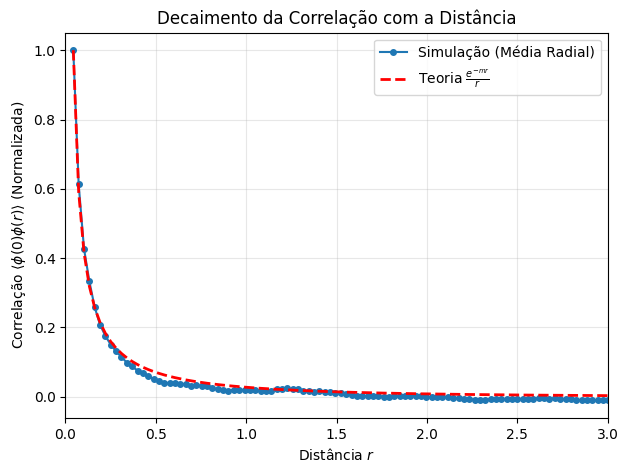

In [18]:
# --- Plot ---
plt.figure(figsize=(7, 5))

plt.plot(r_valido, corr_sim, 'o-', label='Simulação (Média Radial)', markersize=4)
plt.plot(r_valido, corr_teorica, 'r--', label=r'Teoria $\frac{e^{-mr}}{r}$', linewidth=2)

plt.title('Decaimento da Correlação com a Distância')
plt.xlabel('Distância $r$')
plt.ylabel(r'Correlação $\langle \phi(0)\phi(r) \rangle$ (Normalizada)')
plt.xlim(0, 3.0)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## 4. Evolução Temporal

$\quad$ Assim como na Mecânica Quântica básica, a evolução de um dado sistema é feita a partir da multiplicação por uma fase que depende da energia. Acontece que no caso dos operadores de criação e, fato que é relevante para o nosso caso, de aniquilação o mesmoa contece. A evolução do operador aniquilação (LANCASTER) é feita através de 
$$
\hat{a}_p \to e^{-i\omega_p t}\hat{a}_p,
$$
lembrando novamente que nesse sistema de unidade, energia e frequência são equivalentes. 

$\quad$ Primeiramente vamos definir os parâmetros da simulação, tal como a quantidade de frames e o pulo temporal entre cada frase, junto com a configuração inicial do campo. 

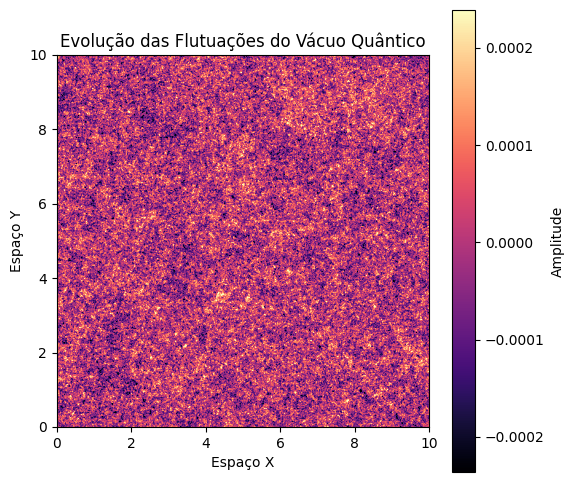

In [25]:
# --- 1. Parâmetros da Simulação ---
num_frames = 120    # Número de quadros da animação
dt = 0.1       # Tamanho do passo de tempo entre os quadros

# Configuração inicial do campo.
phi_k_inicial = phi_k.copy()

#Preparar a Animação
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title("Evolução das Flutuações do Vácuo Quântico")
ax.set_xlabel("Espaço X")
ax.set_ylabel("Espaço Y")

# Geramos o primeiro quadro no tempo t=0 para inicializar a imagem
campo_t0 = np.real(np.fft.ifft2(phi_k_inicial))
# --- A CORREÇÃO: Travando a escala de cores ---
# Usamos percentis do quadro inicial para ignorar picos muito anômalos
# e deixar as ondas principais com o máximo de contraste.
limite_max = np.percentile(campo_t0, 99)
limite_min = np.percentile(campo_t0, 1)

# Passamos vmin e vmax diretamente na criação da imagem
im = ax.imshow(
    campo_t0, 
    cmap='magma', 
    extent=[0, L, 0, L], 
    animated=True, 
    vmin=limite_min, 
    vmax=limite_max
)
fig.colorbar(im, ax=ax, label='Amplitude')


$\quad$ Agora podemos já definir uma função que estabelesce como o campo vai evoluir. Como já destacado, a evolução do campo ocorre simplesmente com a multiplicação pelo fator complexo $e^{-i\omega_k t}.$ Assim:

In [26]:
# --- 5. Função de Atualização (O motor do tempo) ---
def update(frame):
    t = frame * dt
    
    # A MÁGICA DO TEMPO: Multiplicamos a amplitude inicial pela fase
    fase_temporal = np.exp(-1j * omega_k * t)
    phi_k_t = phi_k_inicial * fase_temporal
    
    # Transformada inversa para voltar ao espaço real
    campo_fisico_t = np.real(np.fft.ifft2(phi_k_t))
    
    # Atualiza APENAS os dados da imagem
    im.set_array(campo_fisico_t)
    
    # A linha im.set_clim(...) FOI DELETADA!
    
    return [im]

$\quad$ Por último, efetivamente geramos o gif que descreve a evolução temporal da flutuação do vácuo. 

In [27]:
# Gerando o GIF
ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=100, blit=True)

# Salvando o GIF.
ani.save('vacuo_quantico.gif', writer='pillow', fps=15)

### 4.1 Evolução Simultânea 

In [22]:
# Frequências e Relação de Dispersão (calculados apenas uma vez)
kx = np.fft.fftfreq(N, d=L/N) * 2 * np.pi
ky = np.fft.fftfreq(N, d=L/N) * 2 * np.pi
KX, KY = np.meshgrid(kx, ky)
omega_k = np.sqrt(KX**2 + KY**2 + m**2)

# Configurações da Média Radial
bins = np.linspace(0, L/2, int(N/3))
bin_centers = 0.5 * (bins[1:] + bins[:-1])
r_valido = bin_centers[1:]
corr_teorica = np.exp(-m*r_valido)/r_valido
corr_teorica = corr_teorica / corr_teorica[0]

# --- TRUQUE: Calculando a escala de cores travada ---
# Geramos um universo "fantasma" só para descobrir qual deve ser o limite do colormap
ruido_r_dummy = np.random.normal(0, 1, (N, N))
ruido_i_dummy = np.random.normal(0, 1, (N, N))
phi_k_dummy = ((ruido_r_dummy + 1j * ruido_i_dummy) / np.sqrt(2)) / np.sqrt(2 * omega_k)
espectro_dummy = np.abs(phi_k_dummy)**2
espectro_dummy[0, 0] = 0
autocorr_dummy = np.fft.fftshift(np.real(np.fft.ifft2(espectro_dummy)))

# Fixamos o vmax no percentil 99 para não ofuscar as bordas
vmax_fixo = np.percentile(autocorr_dummy, 99) 
vmin_fixo = np.min(autocorr_dummy) # Capta o fundo do poço negativo

# --- Configuração da Figura (Layout 2x2) ---
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
ax1, ax2, ax3, ax4 = axs.flatten() # Desempacota a matriz 2x2 em 4 eixos individuais
fig.tight_layout(pad=4.0)

soma_espectro = np.zeros((N, N))
plt.close(fig)


Função para atualizar


In [23]:
def atualizar(frame):
    global soma_espectro
    ax1.clear(); ax2.clear(); ax3.clear(); ax4.clear()
    
    # 1. Gera um NOVO universo a cada frame (Ensemble)
    ruido_real = np.random.normal(0, 1, (N, N))
    ruido_imag = np.random.normal(0, 1, (N, N))
    phi_k = ((ruido_real + 1j * ruido_imag) / np.sqrt(2)) / np.sqrt(2 * omega_k)
    
    # 2. Campo Real Instantâneo
    phi_x = np.real(np.fft.ifft2(phi_k))
    
    # 3. Autocorrelação Instantânea
    espectro_inst = np.abs(phi_k)**2
    espectro_inst[0, 0] = 0 
    autocorr_inst = np.fft.fftshift(np.real(np.fft.ifft2(espectro_inst)))
    
    # 4. Média do Ensemble
    soma_espectro += espectro_inst
    espectro_medio = soma_espectro / (frame + 1)
    autocorr_media = np.fft.fftshift(np.real(np.fft.ifft2(espectro_medio)))
    
    # 5. Média Radial da Autocorrelação Instantânea
    x = np.arange(-N//2, N//2) * (L/N)
    y = np.arange(-N//2, N//2) * (L/N)
    XX, YY = np.meshgrid(x, y)
    R = np.sqrt(XX**2 + YY**2)
    
    radial_corr = np.zeros_like(bin_centers)
    for i in range(len(bin_centers)):
        mask = (R >= bins[i]) & (R < bins[i+1])
        if np.any(mask):
            radial_corr[i] = np.mean(autocorr_inst[mask])
            
    corr_sim = radial_corr[1:]
    corr_sim = corr_sim / corr_sim[0]
    
    # --- Plots (Linha 1) ---
    # Top-Left: Campo Físico
    ax1.imshow(phi_x, cmap='RdBu', extent=[-L/2, L/2, -L/2, L/2])
    ax1.set_title(f'Campo Físico Instantâneo\n(Universo {frame+1})')
    
    # Top-Right: Autocorr 2D Instantânea (Agora com vmax fixo!)
    ax2.imshow(autocorr_inst, cmap='viridis', extent=[-L/2, L/2, -L/2, L/2], vmax=vmax_fixo, vmin=vmin_fixo)
    ax2.set_title('Autocorrelação 2D Instantânea\n(Ruidosa)')
    
    # --- Plots (Linha 2) ---
    # Bottom-Left: Autocorr 2D Média
    ax3.imshow(autocorr_media, cmap='viridis', extent=[-L/2, L/2, -L/2, L/2], vmax=vmax_fixo, vmin=vmin_fixo)
    ax3.set_title(f'Média de Ensemble (N={frame+1})\n(Convergindo)')
    
    # Bottom-Right: Curva Radial vs Teoria
    ax4.plot(r_valido, corr_sim, 'o-', label='Inst.', markersize=4)
    ax4.plot(r_valido, corr_teorica, 'r--', label='Teoria', linewidth=2)
    ax4.set_title('Decaimento Radial\n(Instantâneo vs Teoria)')
    ax4.set_xlim(0, 3.0); ax4.set_ylim(-0.2, 1.2)
    ax4.legend(loc='upper right')
    ax4.grid(True, alpha=0.3)

Efitivamente gerar o GIF.

In [24]:
# --- Criando e Salvando a Animação ---
ani = animation.FuncAnimation(fig, atualizar, frames=num_frames, interval=150)

# Salva o arquivo na mesma pasta do seu script
ani.save('evolucao_vacuo_quantico.gif', writer='pillow')


## 5. Conclusão

$\quad$ Foi possível entender ppipipip

## Referências

**[1]** PIRES, Antônio S. T. Evolução das ideias da Física. 2. ed. São Paulo: Livraria da Física, 2011.

**[2]** T. Lancaster e S. J. Blundell, Quantum Field Theory for the Gifted Amateur.
Oxford University Press, 1ª ed., 2014.

**[3]** M. E. Peskin e D. V. Schroeder, An Introduction to Quantum Field Theory. Addison-Wesley, 1995.